In [3]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

def load_and_clean_citations(file_path, column_name="raw_citation", 
                             output_path="deduplicated_citations.csv", show_plots=True):
    """
    Load a CSV file and return cleaned, filtered citations.

    Parameters:
        file_path (str): Path to the CSV file
        column_name (str): Name of the column containing citations

    Returns:
        citations (pd.Series): Filtered original citations
        citations_clean (pd.Series): Cleaned citations
    """

    ### Load data
    df = pd.read_csv(file_path, low_memory=False)

    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in CSV")

    citations = df[column_name].dropna().reset_index(drop=True)

    ### Filter invalid citations 
    def is_valid_citation(text):
        text = str(text).lower().strip()

        # Remove very short entries
        if len(text.split()) < 5:
            return False

        bad_patterns = [
            "book chapter",
            "book chapters",
            "publications",
            "references",
            "bibliography",
            "refereed",
            "journal articles",
            "peer reviewed"
        ]

        if any(p in text for p in bad_patterns):
            return False

        return True

    citations = citations[citations.apply(is_valid_citation)].reset_index(drop=True)

    ### Clean text 
    def clean_citation(text):
        text = str(text).lower()

        ### Remove punctuation
        text = re.sub(r'[^\w\s]', ' ', text)

        ### Collapse whitespace
        text = re.sub(r'\s+', ' ', text)

        return text.strip()

    citations_clean = citations.apply(clean_citation)

    vectorizer = TfidfVectorizer(
        stop_words="english",
        max_features=5000   # prevents noise explosion
    )

    X = vectorizer.fit_transform(citations_clean)
    
    nn = NearestNeighbors(metric="cosine", n_neighbors=5)
    nn.fit(X)

    distances, indices = nn.kneighbors(X)
    
    threshold = 0.15  # distance (cosine distance = 1 - similarity)

    groups = []
    visited = set()

    for i in range(len(citations)):
        if i in visited:
            continue

        group = [i]

        for j, dist in zip(indices[i], distances[i]):
            if j != i and dist < threshold:
                group.append(j)
                visited.add(j)

        visited.add(i)

        if len(group) > 1:
            groups.append(group)
            
    unique_indices = set(range(len(citations)))

    for group in groups:
        for idx in group[1:]:  # keep first, remove rest
            unique_indices.discard(idx)

    unique_citations = citations.iloc[list(unique_indices)]
    df_unique = pd.DataFrame({
        "citation": unique_citations.reset_index(drop=True)
    })
    
    df_unique.to_csv(output_path, index=False)
    print("Total citations in original file: ", len(df))
    print("Number of unique citations: ", len(df_unique))
    print("Saved to: ", output_path)
    
    if show_plots:
        plt.figure()
        plt.bar(["Original", "Unique"], [len(citations), len(df_unique)])
        plt.title("Deduplication Impact")
        plt.ylabel("Number of Citations")
        plt.show()
        
        group_sizes = [len(g) for g in groups]
        plt.figure()
        plt.hist(group_sizes, bins=10)
        plt.title("Duplicate Group Sizes")
        plt.xlabel("Group Size")
        plt.ylabel("Frequency")
        plt.show()
    
    
    return output_path

Total citation in original file:  14002
Number of unique citations:  6072
Saved to:  plottest.csv


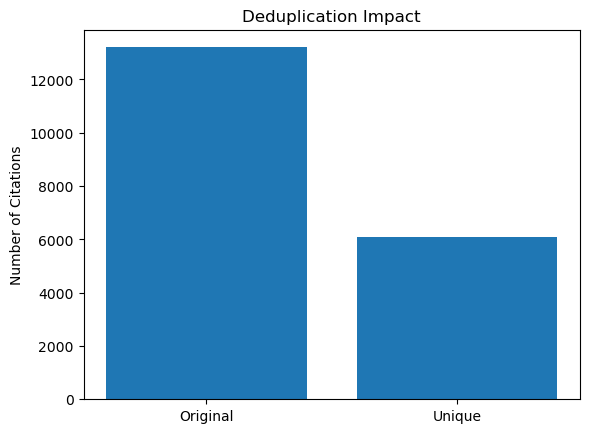

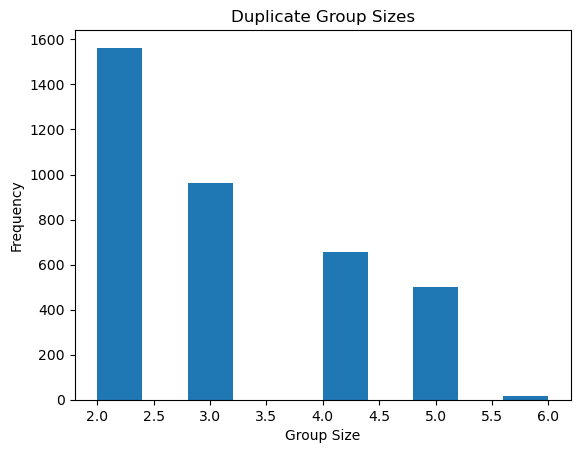

'plottest.csv'

In [4]:
load_and_clean_citations('biblio_stabilized_candidate_citations.csv', output_path='plottest.csv', show_plots=True)

In [6]:
df_biblio = pd.read_csv('biblio_stabilized_candidate_citations.csv', low_memory=False)
len(df_biblio)

14002

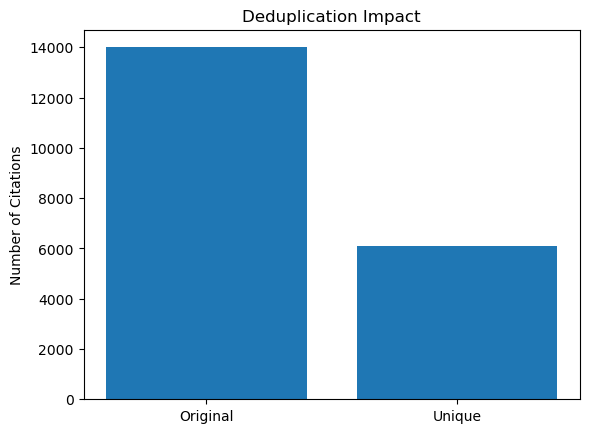

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(["Original", "Unique"], [len(df_biblio), len(output_file)])
plt.title("Deduplication Impact")
plt.ylabel("Number of Citations")
plt.show()